In [26]:
import pandas as pd
import numpy as np
from pathlib import Path
import re
import matplotlib.pyplot as plt


ROOT = Path("../results/20260218_141411/consumer/")  
files = sorted(ROOT.glob("consumer-sts-*_metrics/per_message_latency_run-*_consumer-sts-*.csv"))

print("Found per-message files:", len(files))
for f in files[:10]:
    print(" -", f.name)

def read_one(fpath: Path) -> pd.DataFrame:
    df = pd.read_csv(fpath)

    # Your per-message schema should include these
    needed = {"recv_ts","producer_ts","e2e_ms","topic","partition","offset","producer_pod","index"}
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"{fpath.name} missing columns: {missing}")

    m = re.search(r"(consumer-sts-\d+)", fpath.name)
    df["consumer_pod"] = m.group(1) if m else "unknown"

    # types
    df["recv_ts"] = pd.to_numeric(df["recv_ts"], errors="coerce")
    df["producer_ts"] = pd.to_numeric(df["producer_ts"], errors="coerce")
    df["e2e_ms"] = pd.to_numeric(df["e2e_ms"], errors="coerce")
    df["partition"] = pd.to_numeric(df["partition"], errors="coerce").astype("Int64")
    df["offset"] = pd.to_numeric(df["offset"], errors="coerce").astype("Int64")

    df = df.dropna(subset=["recv_ts","producer_ts","e2e_ms"])
    return df

lat = pd.concat([read_one(f) for f in files], ignore_index=True)
print("Total sampled messages:", len(lat), "pods:", lat["consumer_pod"].nunique())

lat.head()

Found per-message files: 8
 - per_message_latency_run-20260218-132835_consumer-sts-0.csv
 - per_message_latency_run-20260218-132835_consumer-sts-1.csv
 - per_message_latency_run-20260218-132835_consumer-sts-2.csv
 - per_message_latency_run-20260218-132835_consumer-sts-3.csv
 - per_message_latency_run-20260218-132835_consumer-sts-4.csv
 - per_message_latency_run-20260218-132835_consumer-sts-5.csv
 - per_message_latency_run-20260218-132835_consumer-sts-6.csv
 - per_message_latency_run-20260218-132835_consumer-sts-7.csv
Total sampled messages: 8192 pods: 8


,recv_ts,producer_ts,e2e_ms,topic,partition,offset,producer_pod,index,consumer_pod
0,1.771447e+09,1.771447e+09,10.882616,B0-R100-20260218-132835_0,40,9,producer-sts-1,164,consumer-sts-0
1,1.771447e+09,1.771447e+09,13.918638,B0-R100-20260218-132835_0,45,11,producer-sts-1,172,consumer-sts-0
2,1.771447e+09,1.771447e+09,10.456085,B0-R100-20260218-132835_0,45,69,producer-sts-1,1328,consumer-sts-0
3,1.771447e+09,1.771447e+09,11.029243,B0-R100-20260218-132835_0,40,97,producer-sts-0,2007,consumer-sts-0
4,1.771447e+09,1.771447e+09,9.528160,B0-R100-20260218-132835_0,43,97,producer-sts-1,2071,consumer-sts-0


In [29]:
pod_summary = (
    lat.groupby("consumer_pod", as_index=False)
       .agg(
           n=("e2e_ms", "size"),
           p50_ms=("e2e_ms", lambda x: float(x.quantile(0.50))),
           p95_ms=("e2e_ms", lambda x: float(x.quantile(0.95))),
           p99_ms=("e2e_ms", lambda x: float(x.quantile(0.99))),  
           max_ms=("e2e_ms", "max"),
       )
       .sort_values("p99_ms", ascending=False)
)

pod_summary


,consumer_pod,n,p50_ms,p95_ms,p99_ms,max_ms
5,consumer-sts-5,954,15.110016,303.396881,814.252136,1249.117374
0,consumer-sts-0,935,14.760733,222.164726,791.589956,1387.945414
7,consumer-sts-7,1020,15.335083,285.298657,774.871395,1297.401667
1,consumer-sts-1,1120,15.069127,277.152431,765.824881,1430.859327
4,consumer-sts-4,979,15.119791,269.057012,762.544041,1457.695007
2,consumer-sts-2,1129,15.322924,245.032787,715.210962,1388.963461
3,consumer-sts-3,1110,15.262246,229.648805,679.672530,1253.424883
6,consumer-sts-6,945,15.103340,159.860373,567.824297,1092.624664


In [30]:
s = lat["e2e_ms"].to_numpy()

cluster_summary = {
    "n": len(s),
    "p50_ms": np.quantile(s, 0.50),
    "p95_ms": np.quantile(s, 0.95),
    "p99_ms": np.quantile(s, 0.99),
    "p999_ms": np.quantile(s, 0.999) if len(arr) >= 1000 else np.nan,
    "max_ms": float(np.max(s)),
}
cluster_summary


{'n': 8192,
 'p50_ms': 15.128135681152344,
 'p95_ms': 244.58813667297343,
 'p99_ms': 753.0029892921448,
 'p999_ms': 1258.720420598985,
 'max_ms': 1457.6950073242188}

In [31]:
BUCKET_SEC = 30
t0 = lat["recv_ts"].min()
lat["t_bucket"] = (np.floor((lat["recv_ts"] - t0) / BUCKET_SEC) * BUCKET_SEC).astype(int)

# Tail fractions at multiple thresholds (you can tune these)
thresholds = [500, 700, 800, 900, 1000, 1500]

def bucket_metrics(g):
    arr = g["e2e_ms"].to_numpy()
    out = {
        "n": len(arr),
        "true_p95_ms": np.quantile(arr, 0.95),
        "true_p99_ms": np.quantile(arr, 0.99),
        "true_p999_ms": np.quantile(arr, 0.999) if len(arr) >= 1000 else np.nan,
        "max_ms": float(np.max(arr)),
    }
    for thr in thresholds:
        out[f"tail_frac_gt_{thr}"] = float(np.mean(arr > thr))
    return pd.Series(out)

bucket = (lat.groupby("t_bucket")
          .apply(bucket_metrics)
          .reset_index()
          .sort_values("t_bucket"))

bucket.head()


,t_bucket,n,true_p95_ms,true_p99_ms,true_p999_ms,max_ms,tail_frac_gt_500,tail_frac_gt_700,tail_frac_gt_800,tail_frac_gt_900,tail_frac_gt_1000,tail_frac_gt_1500
0,0,73.0,48.873520,240.208721,NaN,468.441963,0.000000,0.000000,0.000000,0.000000,0.00000,0.0
1,30,110.0,307.511783,398.884861,NaN,758.920908,0.009091,0.009091,0.000000,0.000000,0.00000,0.0
2,60,84.0,182.634628,1180.029385,NaN,1343.314409,0.047619,0.023810,0.023810,0.023810,0.02381,0.0
3,90,78.0,392.156994,857.191150,NaN,937.352180,0.051282,0.051282,0.038462,0.012821,0.00000,0.0
4,120,92.0,214.842081,814.280686,NaN,861.835480,0.021739,0.021739,0.021739,0.000000,0.00000,0.0


In [38]:
from pathlib import Path
path = "../results/20260218_141411/"
run_id = Path(path).resolve().name

print(run_id)

20260218_141411


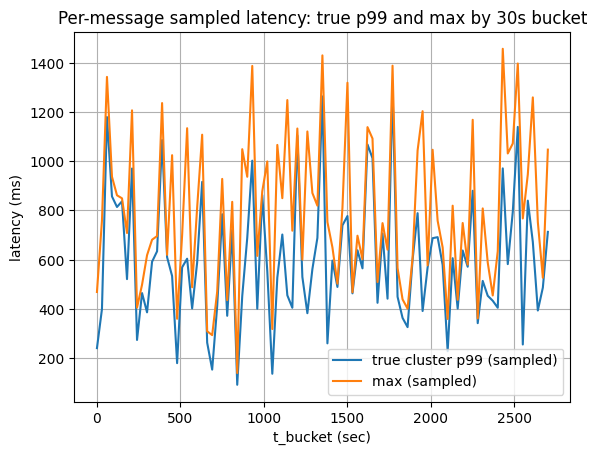

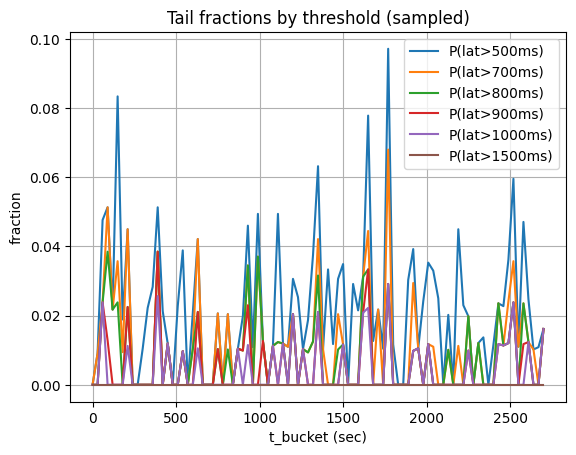

In [43]:
plt.figure()
plt.plot(bucket["t_bucket"], bucket["true_p99_ms"], label="true cluster p99 (sampled)")
plt.plot(bucket["t_bucket"], bucket["max_ms"], label="max (sampled)")
plt.xlabel("t_bucket (sec)")
plt.ylabel("latency (ms)")
plt.title("Per-message sampled latency: true p99 and max by 30s bucket")
plt.grid(True)
plt.legend()
plt.savefig(f"analysis_out/{run_id}/per-message/Per-msg-true p99, max by 30s bucket_{run_id}.pdf", bbox_inches="tight")
plt.show()

plt.figure()
for thr in thresholds:
    plt.plot(bucket["t_bucket"], bucket[f"tail_frac_gt_{thr}"], label=f"P(lat>{thr}ms)")
plt.xlabel("t_bucket (sec)")
plt.ylabel("fraction")
plt.title("Tail fractions by threshold (sampled)")
plt.grid(True)
plt.legend()
plt.savefig(f"analysis_out/{run_id}/per-message/Tail fractions by threshold (sampled)_{run_id}.pdf", bbox_inches="tight")
plt.show()


In [33]:
# Worst buckets by p99 and by max
worst_by_p99 = bucket.sort_values("true_p99_ms", ascending=False).head(10)
worst_by_max = bucket.sort_values("max_ms", ascending=False).head(10)

worst_by_p99, worst_by_max
worst_bucket = int(worst_by_max.iloc[0]["t_bucket"])

tmp = lat[lat["t_bucket"] == worst_bucket].sort_values("e2e_ms", ascending=False).head(30)

tmp[["consumer_pod","e2e_ms","recv_ts","producer_ts","topic","partition","offset","producer_pod","index"]]


,consumer_pod,e2e_ms,recv_ts,producer_ts,topic,partition,offset,producer_pod,index
5182,consumer-sts-4,1457.695007,1.771449e+09,1.771449e+09,B0-R100-20260218-132835_0,50,12226,producer-sts-2,244901
5177,consumer-sts-4,878.607512,1.771449e+09,1.771449e+09,B0-R100-20260218-132835_0,46,12142,producer-sts-1,243640
4170,consumer-sts-3,21.317959,1.771449e+09,1.771449e+09,B0-R100-20260218-132835_0,8,12165,producer-sts-2,243642
1938,consumer-sts-1,21.074772,1.771449e+09,1.771449e+09,B0-R100-20260218-132835_0,27,12156,producer-sts-2,244471
6115,consumer-sts-5,20.975351,1.771449e+09,1.771449e+09,B0-R100-20260218-132835_0,33,12080,producer-sts-2,243457
6116,consumer-sts-5,20.905018,1.771449e+09,1.771449e+09,B0-R100-20260218-132835_0,34,12374,producer-sts-2,243863
6121,consumer-sts-5,20.049810,1.771449e+09,1.771449e+09,B0-R100-20260218-132835_0,33,12174,producer-sts-2,245249
849,consumer-sts-0,20.040989,1.771449e+09,1.771449e+09,B0-R100-20260218-132835_0,42,12263,producer-sts-2,245380
845,consumer-sts-0,19.960403,1.771449e+09,1.771449e+09,B0-R100-20260218-132835_0,39,12212,producer-sts-2,243947
851,consumer-sts-0,19.768715,1.771449e+09,1.771449e+09,B0-R100-20260218-132835_0,42,12270,producer-sts-2,245412


In [35]:
PER_POD_METRICS = "analysis_out/20260218_141411/per_pod_merged_20260218_141411.csv"  # change if needed
per_pod = pd.read_csv(PER_POD_METRICS)

# Make sure per_pod has t_bucket and pod columns (it should)
print(per_pod.columns)

# Merge true per-message bucket metrics with cluster_agg if you have it
# If you want per-pod lag correlation, aggregate per_pod to cluster totals per bucket
cluster_lag = (per_pod.groupby("t_bucket")
               .agg(window_total=("window_total","sum"),
                    window_viol=("window_viol","sum"),
                    total_lag=("total_lag","sum"),
                    max_lag=("max_lag","max"),
                    lag_skew_ratio=("lag_skew_ratio","max"))
               .reset_index())

merged = bucket.merge(cluster_lag, on="t_bucket", how="left")

merged[["t_bucket","true_p99_ms","max_ms","max_lag","total_lag","lag_skew_ratio"]].head()

# Simple correlation view (nan-safe)
cols = ["true_p99_ms","max_ms","max_lag","total_lag","lag_skew_ratio"]
corr = merged[cols].corr(numeric_only=True)
corr


Index(['pod', 'traffic_mode', 'topics', 'window_total', 'window_viol',
       'msg_rate_window', 'lat_window_seconds', 'lat_count_window',
       'lat_p95_ms', 'lat_p99_ms', 'cpu_percent', 'mem_percent', 'uptime_sec',
       'total_lag', 'max_lag', 'lag_skew_ratio', 'consumed_total', 'file',
       'viol_rate', 't_bucket'],
      dtype='object')


,true_p99_ms,max_ms,max_lag,total_lag,lag_skew_ratio
true_p99_ms,1.000000,0.790859,0.123939,0.036325,0.142674
max_ms,0.790859,1.000000,-0.043731,-0.116627,0.105677
max_lag,0.123939,-0.043731,1.000000,0.471311,0.257006
total_lag,0.036325,-0.116627,0.471311,1.000000,-0.230918
lag_skew_ratio,0.142674,0.105677,0.257006,-0.230918,1.000000


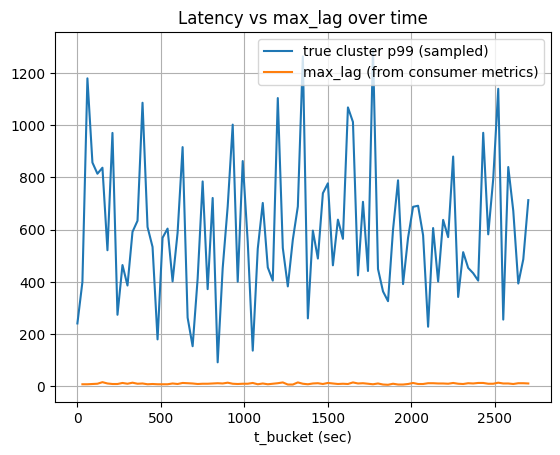

In [42]:
plt.figure()
plt.plot(merged["t_bucket"], merged["true_p99_ms"], label="true cluster p99 (sampled)")
plt.plot(merged["t_bucket"], merged["max_lag"], label="max_lag (from consumer metrics)")
plt.xlabel("t_bucket (sec)")
plt.title("Latency vs max_lag over time")
plt.grid(True)
plt.legend()
plt.savefig(f"analysis_out/{run_id}/per-message/Latency vs max_lag over time_{run_id}.pdf", bbox_inches="tight")
plt.show()
